In [1]:
import requests, bs4, pandas, matplotlib
print("Todo OK")

Todo OK


In [2]:
from bs4 import BeautifulSoup

url = "https://books.toscrape.com/"
response = requests.get(url)

In [3]:
print(response.status_code)  # debe imprimir 200
print(response.text[:500])    # primeros 500 chars del HTML

200
<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->
    <head>
        <title>
    All products | Books to Scrape - Sandbox
</title>

        <meta http-equiv="content-type" content="text/html; charset=UTF-8" /


In [4]:
soup = BeautifulSoup(response.text, "html.parser")
print(soup.title.text)  # imprime el título de la página


    All products | Books to Scrape - Sandbox



In [5]:
rating_map = {"One":1, "Two":2, "Three":3,
               "Four":4, "Five":5}
libros = []

for art in soup.select("article.product_pod"):
    titulo = art.select_one("h3 a")["title"]
    precio = art.select_one("p.price_color").text.strip()
    r_clase = art.select_one("p.star-rating")["class"][1]
    rating  = rating_map.get(r_clase, 0)
    stock   = art.select_one("p.availability").text.strip()

    libros.append({
        "titulo": titulo,
        "precio": precio,
        "rating": rating,
        "stock": stock
    })

print(f"Extraídos {len(libros)} libros")
print(libros[0])

Extraídos 20 libros
{'titulo': 'A Light in the Attic', 'precio': 'Â£51.77', 'rating': 3, 'stock': 'In stock'}


In [6]:
import time

BASE = "https://books.toscrape.com/catalogue/"
url  = "https://books.toscrape.com/catalogue/page-1.html"
todos = []

while url:
    r    = requests.get(url)
    soup = BeautifulSoup(r.text, "html.parser")

    for art in soup.select("article.product_pod"):
        titulo = art.select_one("h3 a")["title"]
        precio = art.select_one("p.price_color").text.strip()
        r_clase = art.select_one("p.star-rating")["class"][1]
        rating  = rating_map.get(r_clase, 0)
        stock   = art.select_one("p.availability").text.strip()

        todos.append({
            "titulo": titulo,
            "precio": precio,
            "rating": rating,
            "stock": stock
    })

#busca el enlace "next"
    sig = soup.select_one("li.next a")
    url = BASE + sig["href"] if sig else None
    time.sleep(0.5)  # pausa entre peticiones

print(f"Total: {len(todos)} libros")  # debe dar 1000

Total: 1000 libros


In [7]:
import pandas as pd

df = pd.DataFrame(todos)

#Limpia el precio: "Â£51.77" → 51.77
df["precio_num"] = (df["precio"]
    .str.replace(r"[^\d.]", "", regex=True)
    .astype(float))

print(df.head())
print(df.describe())

#Guardar
df.to_csv("libros.csv", index=False, encoding="utf-8-sig")
print("✅ Guardado en libros.csv")


                                  titulo   precio  rating     stock  \
0                   A Light in the Attic  Â£51.77       3  In stock   
1                     Tipping the Velvet  Â£53.74       1  In stock   
2                             Soumission  Â£50.10       1  In stock   
3                          Sharp Objects  Â£47.82       4  In stock   
4  Sapiens: A Brief History of Humankind  Â£54.23       5  In stock   

   precio_num  
0       51.77  
1       53.74  
2       50.10  
3       47.82  
4       54.23  
            rating  precio_num
count  1000.000000  1000.00000
mean      2.923000    35.07035
std       1.434967    14.44669
min       1.000000    10.00000
25%       2.000000    22.10750
50%       3.000000    35.98000
75%       4.000000    47.45750
max       5.000000    59.99000
✅ Guardado en libros.csv


Analiza y visualiza datos

Precio medio: £35.07
Más caro: The Perfect Play (Play by Play #1)
rating
1    34.56
2    34.81
3    34.69
4    36.09
5    35.37
Name: precio_num, dtype: float64


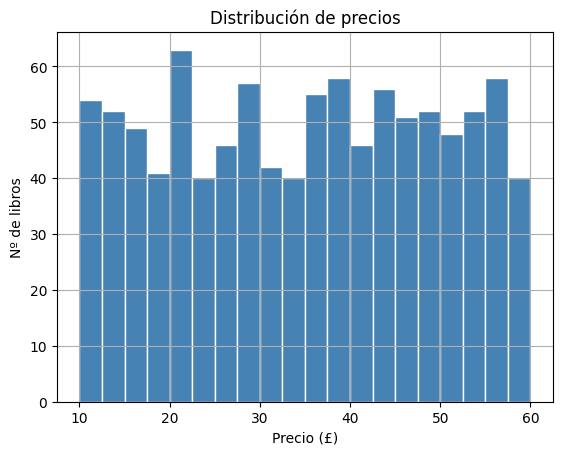

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("libros.csv")

#Estadísticas básicas
print(f"Precio medio: £{df['precio_num'].mean():.2f}")
print(f"Más caro: {df.loc[df['precio_num'].idxmax(), 'titulo']}")
print(df.groupby("rating")["precio_num"].mean().round(2))

#Histograma de precios
df["precio_num"].hist(bins=20, color="steelblue", edgecolor="white")
plt.title("Distribución de precios")
plt.xlabel("Precio (£)")
plt.ylabel("Nº de libros")
plt.savefig("precios.png")
plt.show()


Consulta 1: Los 10 mas caros y titulo 

In [9]:
df.sort_values(by="precio_num", ascending=False, inplace=True)
display(df.head(10)[["titulo", "precio_num"]])

,titulo,precio_num
648,The Perfect Play (Play by Play #1),59.99
617,Last One Home (New Beginnings #1),59.98
860,Civilization and Its Discontents,59.95
560,The Barefoot Contessa Cookbook,59.92
366,The Diary of a Young Girl,59.90
657,The Bone Hunters (Lexy Vaughan & Steven Macaul...,59.71
133,Thomas Jefferson and the Tripoli Pirates: The ...,59.64
387,Boar Island (Anna Pigeon #19),59.48
549,The Man Who Mistook His Wife for a Hat and Oth...,59.45
393,The Improbability of Love,59.45


Consulta 2: Los 10 mas baratos 

In [10]:
df.sort_values(by="precio_num", ascending=False, inplace=False)
display(df.tail(10)[["titulo", "precio_num"]])

,titulo,precio_num
274,Pet Sematary,10.56
434,"NaNo What Now? Finding your editing process, r...",10.41
242,The Lucifer Effect: Understanding How Good Peo...,10.40
479,History of Beauty,10.29
558,The Fellowship of the Ring (The Lord of the Ri...,10.27
302,Greek Mythic History,10.23
84,Patience,10.16
716,The Tipping Point: How Little Things Can Make ...,10.02
501,The Origin of Species,10.01
638,An Abundance of Katherines,10.00


Consulta 3 : Valoraciones y grafica

In [11]:
conteo_valoraciones = df["rating"].value_counts().sort_index()
display(conteo_valoraciones)


rating
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64

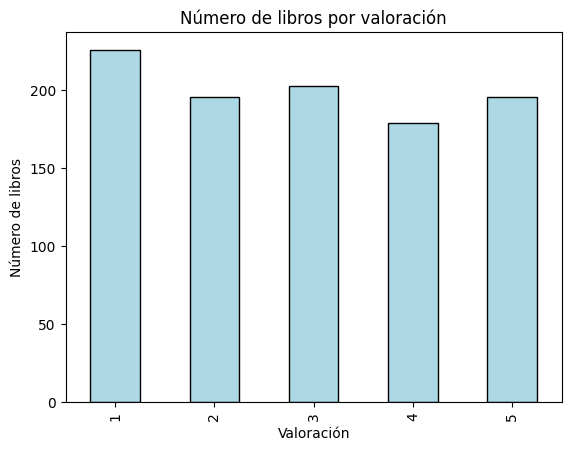

In [12]:
plt.figure()
conteo_valoraciones.plot(kind="bar", color="lightblue", edgecolor="black")
plt.title("Número de libros por valoración")
plt.xlabel("Valoración")
plt.ylabel("Número de libros")

plt.show()

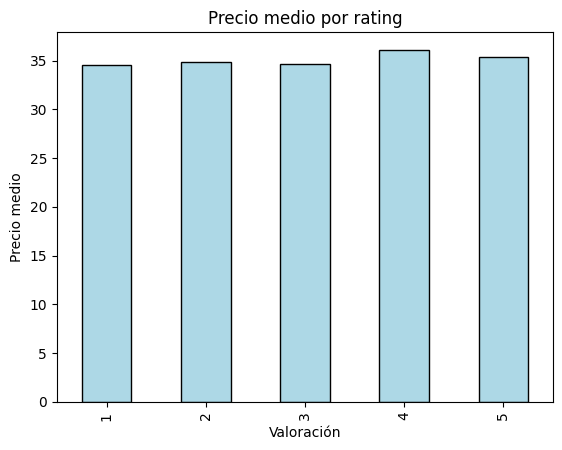

In [13]:
df.groupby("rating")["precio_num"].mean().plot(kind="bar", color="lightblue", edgecolor="black")
plt.title("Precio medio por rating")
plt.xlabel("Valoración")
plt.ylabel("Precio medio")
plt.show()

Consulta 4: Top libros mejor valorados y caros

In [14]:
df[df["rating"] == 5].sort_values(by="precio", ascending=False).head(10)

,titulo,precio,rating,stock,precio_num
560,The Barefoot Contessa Cookbook,Â£59.92,5,In stock,59.92
812,Life Without a Recipe,Â£59.04,5,In stock,59.04
637,Approval Junkie: Adventures in Caring Too Much,Â£58.81,5,In stock,58.81
379,How to Speak Golf: An Illustrated Guide to Lin...,Â£58.32,5,In stock,58.32
631,Digital Fortress,Â£58.00,5,In stock,58.00
545,The Sound Of Love,Â£57.84,5,In stock,57.84
910,Travels with Charley: In Search of America,Â£57.82,5,In stock,57.82
309,El Deafo,Â£57.62,5,In stock,57.62
898,H is for Hawk,Â£57.42,5,In stock,57.42
100,Immunity: How Elie Metchnikoff Changed the Cou...,Â£57.36,5,In stock,57.36


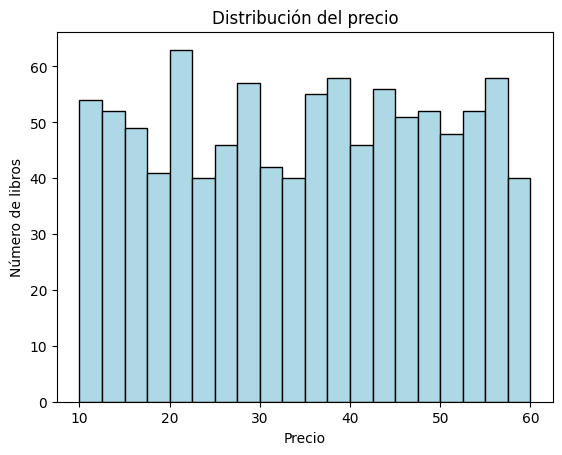

In [15]:
plt.figure()
df["precio_num"].plot(kind="hist", bins=20, color="lightblue", edgecolor="black")
plt.title("Distribución del precio")
plt.xlabel("Precio")
plt.ylabel("Número de libros")
plt.show()